# NYC Taxi Data Science Project

## Objective
Build a full data science pipeline:
- Data loading
- Cleaning
- Feature engineering
- Feature selection
- Modeling
- Evaluation
- Visualization

In [1]:
import sys
import os

sys.path.append(os.path.abspath(".."))

In [2]:
from src.data_loader import load_data
from src.cleaning import clean_data
from src.feature_engineering import add_features
from src.feature_selection import select_features
from src.model import train_model, save_model
from src.evaluation import evaluate_model
from src.visualization import plot_duration, plot_distance_vs_duration

## Step 1: Load Dataset
We load the NYC Taxi dataset from the raw data folder.

In [3]:
df = load_data("../data/NYC.csv")
df.head()

Data Loaded: (1458644, 11)


,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration
0,id2875421,2,2016-03-14 17:24:55,2016-03-14 17:32:30,1,-73.982155,40.767937,-73.964630,40.765602,N,455
1,id2377394,1,2016-06-12 00:43:35,2016-06-12 00:54:38,1,-73.980415,40.738564,-73.999481,40.731152,N,663
2,id3858529,2,2016-01-19 11:35:24,2016-01-19 12:10:48,1,-73.979027,40.763939,-74.005333,40.710087,N,2124
3,id3504673,2,2016-04-06 19:32:31,2016-04-06 19:39:40,1,-74.010040,40.719971,-74.012268,40.706718,N,429
4,id2181028,2,2016-03-26 13:30:55,2016-03-26 13:38:10,1,-73.973053,40.793209,-73.972923,40.782520,N,435


In [4]:
print(df.columns)

Index(['id', 'vendor_id', 'pickup_datetime', 'dropoff_datetime',
       'passenger_count', 'pickup_longitude', 'pickup_latitude',
       'dropoff_longitude', 'dropoff_latitude', 'store_and_fwd_flag',
       'trip_duration'],
      dtype='object')


## Step 2: Data Cleaning
We remove duplicates, handle missing values, and filter invalid records.

In [5]:
df = clean_data(df)
df.head()

After Cleaning: (1458644, 11)


,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration
0,id2875421,2,2016-03-14 17:24:55,2016-03-14 17:32:30,1,-73.982155,40.767937,-73.964630,40.765602,N,455
1,id2377394,1,2016-06-12 00:43:35,2016-06-12 00:54:38,1,-73.980415,40.738564,-73.999481,40.731152,N,663
2,id3858529,2,2016-01-19 11:35:24,2016-01-19 12:10:48,1,-73.979027,40.763939,-74.005333,40.710087,N,2124
3,id3504673,2,2016-04-06 19:32:31,2016-04-06 19:39:40,1,-74.010040,40.719971,-74.012268,40.706718,N,429
4,id2181028,2,2016-03-26 13:30:55,2016-03-26 13:38:10,1,-73.973053,40.793209,-73.972923,40.782520,N,435


## Step 3: Feature Engineering
We create new features like hour, weekday, and speed.

In [6]:
df = add_features(df)
df.head()

,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration,distance_km,hour,weekday
0,id2875421,2,2016-03-14 17:24:55,2016-03-14 17:32:30,1,-73.982155,40.767937,-73.964630,40.765602,N,455,1.498521,17,0
1,id2377394,1,2016-06-12 00:43:35,2016-06-12 00:54:38,1,-73.980415,40.738564,-73.999481,40.731152,N,663,1.805507,0,6
2,id3858529,2,2016-01-19 11:35:24,2016-01-19 12:10:48,1,-73.979027,40.763939,-74.005333,40.710087,N,2124,6.385098,11,1
3,id3504673,2,2016-04-06 19:32:31,2016-04-06 19:39:40,1,-74.010040,40.719971,-74.012268,40.706718,N,429,1.485498,19,2
4,id2181028,2,2016-03-26 13:30:55,2016-03-26 13:38:10,1,-73.973053,40.793209,-73.972923,40.782520,N,435,1.188588,13,5


## Step 4: Data Visualization
We explore relationships in the data.

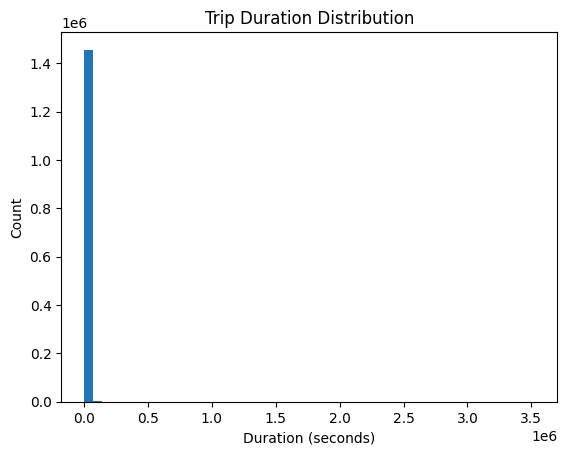

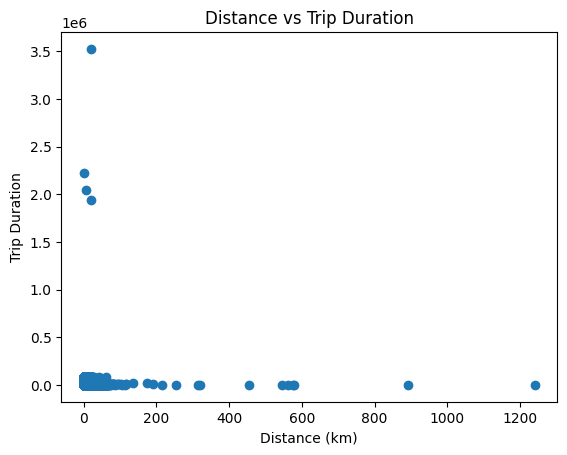

In [7]:
plot_duration(df)
plot_distance_vs_duration(df)

## Step 5: Feature Selection
We select the most important features using two methods.

In [8]:
features = [
    "distance_km",
    "passenger_count",
    "hour",
    "weekday"
]

X = df[features]
y = df["trip_duration"]

selected_features = select_features(X, y)
selected_features

KBest: ['distance_km', 'passenger_count', 'hour', 'weekday']
RF: ['weekday', 'passenger_count', 'hour', 'distance_km']


['distance_km', 'passenger_count', 'hour', 'weekday']

## Step 6: Model Training
We train a Random Forest model.

In [13]:
features = ["distance_km", "passenger_count", "hour", "weekday"]
target = "trip_duration"

model, X_test, y_test = train_model(df, features, target)

save_model(model, "../model/model.pkl")

## Step 7: Model Evaluation
We evaluate the model using MAE, MSE, RMSE, and R².

In [10]:
evaluate_model(model, X_test, y_test)

===== MODEL EVALUATION =====
MAE: 482.8113722399489
MSE: 11376542.23837688
RMSE: 3372.9130196874157
R2 Score: -0.10350088388429901


{'MAE': 482.8113722399489,
 'MSE': 11376542.23837688,
 'RMSE': np.float64(3372.9130196874157),
 'R2': -0.10350088388429901}